# Randomized First Choice vs exact choice probabilities

Randomized First Choice (RFC; Huber, Orme and Miller, 1999) simulates shares by
perturbing utilities and counting first choices:

$$U_i = X_i(\beta + E_A) + E_P,$$

with $E_A$ (attribute variability) shared by every alternative in a draw and
$E_P$ (product variability) drawn per alternative. With normal $E_A$ and
normal $E_P$ (**variant a**) the model has closed-form choice probabilities:
$U \sim N(X\beta,\; X\Sigma_A X^\top + \sigma_P^2 I)$ and

$$P(\text{choose } k) = P(U_k - U_j \ge 0\ \ \forall j \ne k),$$

a $(K-1)$-dimensional orthant probability of the difference vector $A_k U$
with covariance $A_k \Sigma_U A_k^\top$. RFC estimates these by Monte Carlo.
**Variant b** uses Gumbel $E_P$ with the same variance, as RFC is often run;
it has no closed form here and is simulated only.

"Exact" below means the exact probabilities of model (a). They are computed
two ways:

- `scipy.stats.multivariate_normal.cdf` with tolerance 1e-6: the reference.
- `quantecarlo.orthant_cdf`: a hosted batch service, approximate. Its own
  error against SciPy is reported, not assumed away.

All data are synthetic, because `orthant_cdf` sends its inputs to a hosted
service. Logic is in `rfc.py`.

In [1]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import rfc
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 4)
rng = np.random.default_rng(2026)
print("coefficients:", dict(zip([f"{a}{i}" for i, a in enumerate(rfc.COEF_ATTR)], rfc.BETA)))
print("sd of each part-worth (Sigma_A diagonal):", rfc.SD_A, " sigma_P:", rfc.SIGMA_P)

coefficients: {'brand0': np.float64(0.8), 'brand1': np.float64(0.4), 'brand2': np.float64(-0.2), 'A23': np.float64(0.6), 'A24': np.float64(0.3), 'A35': np.float64(0.5), 'A36': np.float64(-0.3), 'A47': np.float64(0.15), 'A58': np.float64(0.1), 'price9': np.float64(-1.2)}
sd of each part-worth (Sigma_A diagonal): [0.6 0.6 0.6 0.4 0.4 0.3 0.3 0.1 0.1 0.5]  sigma_P: 0.5


## 1. Choice sets and exact shares

There are 150 sets of $K = 5$ alternatives, 50 of each kind:

- **plain**: five random profiles.
- **twin**: alternative 1 is an exact copy of alternative 0.
- **near**: alternative 1 is alternative 0 with the two least important
  attributes (A4, A5) flipped.

The design has 5 attributes (4, 3, 3, 2 and 2 levels, dummy-coded) plus a
linear price: 10 part-worths. Before anything else, one `orthant_cdf` call
(all 750 orthants, each with its own covariance) is checked against SciPy.

In [2]:
X, kind = rfc.make_sets(150, rng)
exact, t_scipy = rfc.timed(lambda: rfc.shares_scipy(X))
rfc.shares_orthant(X[:2])                                   # wake the service
oc, t_oc = rfc.timed(lambda: rfc.shares_orthant(X))
e = np.abs(oc - exact)
print(f"SciPy: {t_scipy:.1f} s for {exact.size} orthants ({t_scipy/exact.size*1e3:.1f} ms each); "
      f"rows sum to 1 within {np.abs(exact.sum(1)-1).max():.1e}")
print(f"orthant_cdf: {t_oc:.2f} s for all {exact.size} (one call); "
      f"error vs SciPy median {np.median(e):.4f}, 95th pct {np.quantile(e, .95):.4f}, max {e.max():.4f}")

SciPy: 13.9 s for 750 orthants (18.5 ms each); rows sum to 1 within 3.4e-06
orthant_cdf: 0.10 s for all 750 (one call); error vs SciPy median 0.0007, 95th pct 0.0059, max 0.0183


## 2. Convergence of RFC to the exact shares

RFC shares for all 150 sets at increasing $R$, compared with the SciPy
shares. For variant a the error is pure Monte Carlo noise and should fall like
$1/\sqrt{R}$. For variant b it levels off at the gap between the two models.
The dashed lines show `orthant_cdf`'s error from section 1 for comparison.

In [3]:
Rs = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000, 300_000, 1_000_000]
rows, last = [], {}
for variant in ("a", "b"):
    for R in Rs:
        sh, t = rfc.timed(lambda: rfc.rfc_shares(X, R, rng, variant))
        err = np.abs(sh - exact)
        rows.append(dict(variant=variant, R=R, max_err=err.max(), median_err=np.median(err),
                         mean_err=err.mean(), seconds=t))
        last[variant] = sh
conv = pd.DataFrame(rows)
conv

,variant,R,max_err,median_err,mean_err,seconds
0,a,100,0.1543,0.0154,0.0247,0.0021
1,a,300,0.0814,0.0089,0.0131,0.0034
2,a,1000,0.0361,0.0043,0.0068,0.0083
3,a,3000,0.0203,0.0029,0.0042,0.0230
4,a,10000,0.0149,0.0016,0.0024,0.0803
5,a,30000,0.0064,0.0008,0.0012,0.2717
6,a,100000,0.0048,0.0004,0.0007,0.9065
7,a,300000,0.0022,0.0002,0.0004,2.8612
8,a,1000000,0.0015,0.0001,0.0002,9.1622
9,b,100,0.1356,0.0173,0.0234,0.0018


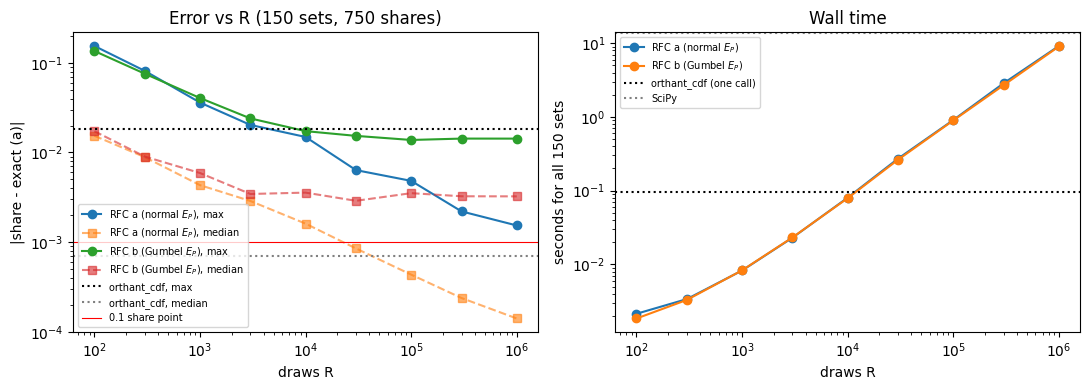

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for v, lab in (("a", "RFC a (normal $E_P$)"), ("b", "RFC b (Gumbel $E_P$)")):
    c = conv[conv.variant == v]
    ax[0].loglog(c.R, c.max_err, "o-", label=f"{lab}, max")
    ax[0].loglog(c.R, c.median_err, "s--", alpha=.6, label=f"{lab}, median")
    ax[1].loglog(c.R, c.seconds, "o-", label=lab)
ax[0].axhline(e.max(), color="k", ls=":", label="orthant_cdf, max")
ax[0].axhline(np.median(e), color="gray", ls=":", label="orthant_cdf, median")
ax[0].axhline(0.001, color="r", lw=.8, label="0.1 share point")
ax[0].set(xlabel="draws R", ylabel="|share - exact (a)|", title="Error vs R (150 sets, 750 shares)")
ax[0].legend(fontsize=7)
ax[1].axhline(t_oc, color="k", ls=":", label="orthant_cdf (one call)")
ax[1].axhline(t_scipy, color="gray", ls=":", label="SciPy")
ax[1].set(xlabel="draws R", ylabel="seconds for all 150 sets", title="Wall time")
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Gap between RFC variant b and exact (a)

At $R = 10^6$ the Monte Carlo noise is about $5\times10^{-4}$ at most. Any
gap well above that is the change of model: Gumbel $E_P$ in place of normal,
with the same variance.

In [5]:
gap = pd.DataFrame({k: dict(max=np.abs(last[v] - exact)[kind == k if k != "all" else slice(None)].max(),
                            mean=np.abs(last[v] - exact)[kind == k if k != "all" else slice(None)].mean())
                    for k in ("all", "plain", "twin", "near") for v in ["b"]}).T
gap.columns = ["max |RFC b - exact a|", "mean |RFC b - exact a|"]
gap["max |RFC a - exact a| (MC noise)"] = [np.abs(last["a"] - exact)[kind == k if k != "all" else slice(None)].max()
                                           for k in ("all", "plain", "twin", "near")]
gap

,max |RFC b - exact a|,mean |RFC b - exact a|,max |RFC a - exact a| (MC noise)
all,0.0143,0.0035,0.0015
plain,0.0092,0.0033,0.0012
twin,0.0096,0.0036,0.0010
near,0.0143,0.0036,0.0015


## 4. Duplicates and near-duplicates

For **twin** sets the combined share of the two copies is compared with the
share the single profile gets when the copy is removed ($K = 4$, exact). The
increase is the share a pure copy "steals" by existing.

How the twins split their combined share depends on $\sigma_P$ alone: their
utility difference is $U_0 - U_1 = E_{P,0} - E_{P,1}$, because $E_A$ moves
both copies together. How much share the pair takes from the *other* products
depends on both variances. A second table varies $\sigma_P$ with $\Sigma_A$
at its true value and at zero. RFC only reproduces whatever the model implies,
so the question for RFC is whether its estimate matches the exact value.

For **near** sets the quantity is the share difference between the near-twins
(alternative 0 minus alternative 1). RFC uses $R = 10^6$.

In [6]:
tw, nr = kind == "twin", kind == "near"
X_drop = X[tw][:, [0, 2, 3, 4], :]                         # twin removed
single = rfc.shares_scipy(X_drop)[:, 0]
twins = pd.DataFrame({
    "single (copy removed)": single,
    "exact a: twins combined": exact[tw, :2].sum(1),
    "RFC a": last["a"][tw, :2].sum(1),
    "RFC b": last["b"][tw, :2].sum(1),
})
print("twin sets: mean over 50 sets")
display(twins.mean().to_frame("mean share").T)
print("mean |RFC - exact a| on combined twin share:  a %.4f   b %.4f" % (
    np.abs(twins["RFC a"] - twins["exact a: twins combined"]).mean(),
    np.abs(twins["RFC b"] - twins["exact a: twins combined"]).mean()))

gain_rows = []
for sp in (0.1, 0.25, 0.5, 1.0):
    for lab, sda in (("true Sigma_A", rfc.SD_A), ("Sigma_A = 0", np.zeros(rfc.P))):
        both = rfc.shares_scipy(X[tw], sd_a=sda, sigma_p=sp)[:, :2].sum(1)
        one = rfc.shares_scipy(X_drop, sd_a=sda, sigma_p=sp)[:, 0]
        gain_rows.append(dict(sigma_P=sp, Sigma_A=lab, single=one.mean(), twins_combined=both.mean(),
                              gain_from_copy=(both - one).mean()))
print("exact (a): share gained by adding an exact copy, mean over 50 twin sets")
display(pd.DataFrame(gain_rows).pivot(index="sigma_P", columns="Sigma_A", values="gain_from_copy"))

near = pd.DataFrame({"exact a": exact[nr, 0] - exact[nr, 1],
                     "RFC a": last["a"][nr, 0] - last["a"][nr, 1],
                     "RFC b": last["b"][nr, 0] - last["b"][nr, 1]})
print("\nnear sets: share(alt 0) - share(alt 1)")
display(near.describe().loc[["mean", "std", "min", "max"]])
print("mean |RFC - exact a| on the difference:  a %.4f   b %.4f" % (
    np.abs(near["RFC a"] - near["exact a"]).mean(), np.abs(near["RFC b"] - near["exact a"]).mean()))

twin sets: mean over 50 sets


,single (copy removed),exact a: twins combined,RFC a,RFC b
mean share,0.3031,0.3556,0.3555,0.3538


mean |RFC - exact a| on combined twin share:  a 0.0002   b 0.0072


exact (a): share gained by adding an exact copy, mean over 50 twin sets


Sigma_A,Sigma_A = 0,true Sigma_A
sigma_P,,
0.10,0.0037,0.0108
0.25,0.0220,0.0271
0.50,0.0524,0.0525
1.00,0.0961,0.0904



near sets: share(alt 0) - share(alt 1)


,exact a,RFC a,RFC b
mean,5.0224e-05,0.0002,-0.0004
std,8.2974e-02,0.0829,0.0843
min,-2.4205e-01,-0.2414,-0.2613
max,2.2343e-01,0.2240,0.2352


mean |RFC - exact a| on the difference:  a 0.0002   b 0.0022


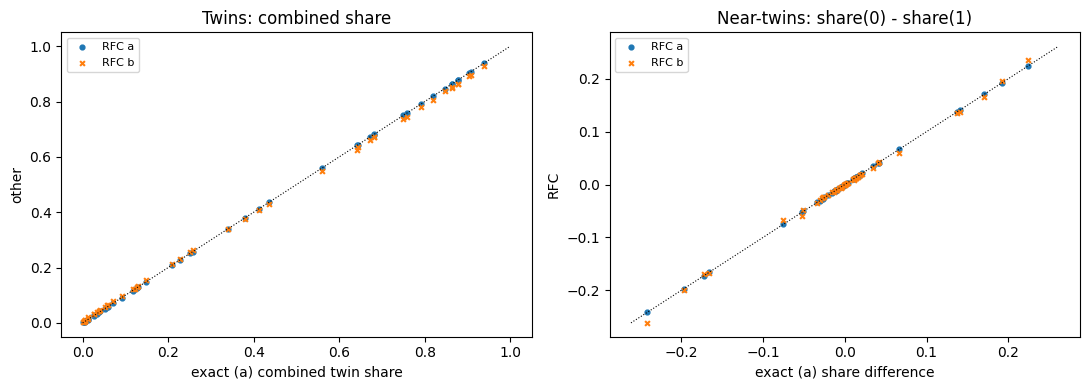

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(twins["exact a: twins combined"], twins["RFC a"], s=12, label="RFC a")
ax[0].scatter(twins["exact a: twins combined"], twins["RFC b"], s=12, marker="x", label="RFC b")
lim = [0, 1]; ax[0].plot(lim, lim, "k:", lw=.8)
ax[0].set(xlabel="exact (a) combined twin share", ylabel="other", title="Twins: combined share"); ax[0].legend(fontsize=8)
ax[1].scatter(near["exact a"], near["RFC a"], s=12, label="RFC a")
ax[1].scatter(near["exact a"], near["RFC b"], s=12, marker="x", label="RFC b")
m = np.abs(near.values).max(); ax[1].plot([-m, m], [-m, m], "k:", lw=.8)
ax[1].set(xlabel="exact (a) share difference", ylabel="RFC", title="Near-twins: share(0) - share(1)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Timing at scale

In this setup the "scenarios" are respondents: **one** design $X$ with $K = 5$
products, and $N$ respondents with their own part-worths
$\beta_i = \beta + 0.3\,z_i$. $\Sigma_U$ is then shared, so `orthant_cdf`
needs one call per alternative (5 calls) whatever $N$ is.

The RFC target is 0.1 share points: a Monte Carlo standard error of 0.001 on
every share. That requires $R = 0.5^2 / 0.001^2 = 250{,}000$ draws per
respondent, set by the worst case $p = 0.5$. That is a typical error of
0.001; the worst share of a large market will be off by about four times
that. If what matters is the share **averaged over respondents**, the noise
averages too, and far fewer draws per respondent are needed (last column).

Some cells are measured and others extrapolated linearly from a measured
subset; the `how` column says which. SciPy is timed on 40 respondents (200
orthants). `orthant_cdf` with a per-row covariance is also shown, as for
choice sets that each have their own design. It sends a 4×4 matrix per row,
so it is measured up to $10^5$.

In [8]:
X1 = X[np.where(kind == "plain")[0][0]]
R_target = int(0.5**2 / 0.001**2)
Bsub = rfc.respondent_betas(40, rng)
ref_sub, t_sp = rfc.timed(lambda: rfc.respondent_shares_scipy(X1, Bsub))
sp_per = t_sp / len(Bsub)
_, t_rfc200 = rfc.timed(lambda: rfc.respondent_shares_rfc(X1, rfc.respondent_betas(200, rng), R_target, rng))
rfc_per = t_rfc200 / 200

rfc.respondent_shares_orthant(X1, Bsub)                       # warm
oc_sub = rfc.respondent_shares_orthant(X1, Bsub)
print(f"orthant_cdf (shared cov) vs SciPy on 40 respondents: median {np.median(np.abs(oc_sub-ref_sub)):.4f}, "
      f"max {np.abs(oc_sub-ref_sub).max():.4f}")

def per_row_call(B):
    V = B @ X1.T
    S = np.broadcast_to(X1 @ np.diag(rfc.SD_A**2) @ X1.T + rfc.SIGMA_P**2 * np.eye(5), (len(B), 5, 5))
    up, cov = rfc.orthant_problems(V, S)
    return rfc.orthant_cdf(up, cov)

rows = []
for N in (1_000, 100_000, 1_000_000):
    B = rfc.respondent_betas(N, rng)
    _, t_oc_shared = rfc.timed(lambda: rfc.respondent_shares_orthant(X1, B))
    if N <= 100_000:
        _, t_pr = rfc.timed(lambda: per_row_call(B)); how_pr = "measured"
    else:
        t_pr, how_pr = t_pr * N / 100_000, "extrapolated from 1e5"
    if N == 1_000:
        _, t_r = rfc.timed(lambda: rfc.respondent_shares_rfc(X1, B, R_target, rng)); how_r = "measured"
    else:
        t_r, how_r = rfc_per * N, "extrapolated from 200"
    R_agg = int(np.ceil(R_target / N))   # draws per respondent for SE 0.001 on the respondent-averaged share
    rows.append({"N": f"{N:.0e}",
                 f"RFC a, R={R_target:,} (s)": t_r, "RFC how": how_r,
                 "SciPy (s)": sp_per * N, "SciPy how": "extrapolated from 40",
                 "orthant_cdf shared cov, 5 calls (s)": t_oc_shared,
                 "orthant_cdf per-row cov, 1 call (s)": t_pr, "per-row how": how_pr,
                 "RFC a for averaged share: R/resp": R_agg,
                 "RFC a for averaged share (s)": rfc_per * N * R_agg / R_target})
timing = pd.DataFrame(rows).set_index("N")
timing

orthant_cdf (shared cov) vs SciPy on 40 respondents: median 0.0001, max 0.0026


,"RFC a, R=250,000 (s)",RFC how,SciPy (s),SciPy how,"orthant_cdf shared cov, 5 calls (s)","orthant_cdf per-row cov, 1 call (s)",per-row how,RFC a for averaged share: R/resp,RFC a for averaged share (s)
N,,,,,,,,,
1e+03,14.8445,measured,51.3213,extrapolated from 40,1.2342,0.2220,measured,250,0.0148
1e+05,1477.5090,extrapolated from 200,5132.1271,extrapolated from 40,7.0949,7.8262,measured,3,0.0177
1e+06,14775.0900,extrapolated from 200,51321.2707,extrapolated from 40,15.4256,78.2616,extrapolated from 1e5,1,0.0591


## 6. Fitting the variances instead of a grid search

Holdout choices come from simulated respondents: 300 per task, on 40
**fitting** tasks and 40 separate **test** tasks. The part-worths $\beta$ are
taken as known, standing in for an upstream estimate. The variances are tuned
on the fitting tasks and scored by mean absolute share error (MAE) on the test
tasks.

- **exact, diag**: maximize the multinomial log-likelihood of the fitting
  choices over one sd per part-worth plus $\sigma_P$ (11 parameters). Each
  evaluation is one `orthant_cdf` call with per-row covariance; L-BFGS-B uses
  finite differences.
- **exact, 2-param**: the same, with one common sd for every part-worth plus
  $\sigma_P$. That is the parameterization an RFC grid search tunes, so this
  row separates "better integrator" from "more parameters".
- **RFC a / RFC b, grid**: an 8×8 grid of (common sd, $\sigma_P$), $R = 20{,}000$
  with common random numbers, chosen by MAE on the fitting tasks (the usual
  practice). Test shares use $R = 200{,}000$ fresh draws.
- **truth**: exact shares at the true parameters. This is the floor set by
  sampling noise in 300 respondents per task.

Exact-model predictions on the test tasks use `orthant_cdf`, the method under
test; the truth row uses SciPy. The holdout data are generated twice:

- from model (a), which the exact fits assume;
- from model (b) (Gumbel $E_P$), where the exact model is misspecified and RFC
  b is the true model.

In [9]:
X_fit, _ = rfc.make_sets(40, rng)
X_test, _ = rfc.make_sets(40, rng)
grid_a = np.geomspace(0.05, 1.5, 8)
grid_p = np.geomspace(0.1, 1.5, 8)
fit_rows, fitted = [], {}
for dgp in ("a", "b"):
    c_fit = rfc.simulate_choices(X_fit, 300, rng, dgp)
    c_test = rfc.simulate_choices(X_test, 300, rng, dgp)
    obs = c_test / c_test.sum(1, keepdims=True)
    mae = lambda sh: np.mean(np.abs(sh - obs))
    if dgp == "a":
        truth = rfc.shares_scipy(X_test)
    else:
        truth = rfc.rfc_shares(X_test, 1_000_000, rng, "b")
    fit_rows.append(dict(dgp=dgp, method="truth", test_MAE=mae(truth), sigma_P=rfc.SIGMA_P,
                         common_sd=np.nan, seconds=np.nan, evaluations=np.nan))
    for structure in ("diag", "2"):
        (sd_a, sp, res, n_calls), t = rfc.timed(lambda: rfc.fit_exact(X_fit, c_fit, structure))
        pred = rfc.shares_orthant(X_test, sd_a=sd_a, sigma_p=sp)
        fitted[(dgp, structure)] = sd_a
        fit_rows.append(dict(dgp=dgp, method=f"exact, {structure}", test_MAE=mae(pred), sigma_P=sp,
                             common_sd=sd_a[0] if structure == "2" else np.nan, seconds=t, evaluations=n_calls))
    for variant in ("a", "b"):
        (a, sp, table), t = rfc.timed(lambda: rfc.grid_rfc(X_fit, c_fit, grid_a, grid_p, 20_000, rng, variant))
        pred = rfc.rfc_shares(X_test, 200_000, rng, variant, sd_a=np.full(rfc.P, a), sigma_p=sp)
        edge = a in (grid_a[0], grid_a[-1]) or sp in (grid_p[0], grid_p[-1])
        fit_rows.append(dict(dgp=dgp, method=f"RFC {variant}, grid" + (" (on grid edge)" if edge else ""),
                             test_MAE=mae(pred), sigma_P=sp, common_sd=a, seconds=t, evaluations=table.size))
fits = pd.DataFrame(fit_rows)
fits

,dgp,method,test_MAE,sigma_P,common_sd,seconds,evaluations
0,a,truth,0.0129,0.5000,NaN,NaN,NaN
1,a,"exact, diag",0.0136,0.5651,NaN,104.4933,468.0
2,a,"exact, 2",0.0158,0.5441,0.3969,13.2611,60.0
3,a,"RFC a, grid",0.0202,0.4700,0.3492,3.0957,64.0
4,a,"RFC b, grid",0.0191,0.4700,0.3492,3.0882,64.0
5,b,truth,0.0111,0.5000,NaN,NaN,NaN
6,b,"exact, diag",0.0137,0.6013,NaN,260.6130,1200.0
7,b,"exact, 2",0.0165,0.5783,0.4464,7.7578,36.0
8,b,"RFC a, grid",0.0167,0.3192,0.5676,3.1163,64.0
9,b,"RFC b, grid",0.0169,0.3192,0.5676,3.0759,64.0


In [10]:
sd_tab = pd.DataFrame({"attribute": rfc.COEF_ATTR, "true sd": rfc.SD_A,
                       "exact diag, data a": fitted[("a", "diag")], "exact diag, data b": fitted[("b", "diag")]})
sd_tab

,attribute,true sd,"exact diag, data a","exact diag, data b"
0,brand,0.6,0.5757,0.4968
1,brand,0.6,0.5087,0.5757
2,brand,0.6,0.5362,0.5758
3,A2,0.4,0.3961,0.4157
4,A2,0.4,0.3996,0.4257
5,A3,0.3,0.2702,0.3038
6,A3,0.3,0.0156,0.2729
7,A4,0.1,0.0441,0.0062
8,A5,0.1,0.0212,0.1696
9,price,0.5,0.4334,0.5193


## 6. HB posterior draws and share uncertainty

**The draws below are synthetic stand-ins for HB output, not a fitted
posterior.** There are 1,000 respondents with $\beta_n \sim N(\mu, 0.4^2 I)$.
Each gets 500 pseudo-posterior draws $\beta_n + \delta_s + \varepsilon_{ns}$:

- $\delta_s \sim N(0, 0.08^2 I)$ is shared by every respondent in draw $s$. It
  stands in for the posterior uncertainty of the population mean that real HB
  draws carry. Without it, draws that are independent across respondents
  average out in the market share and make the intervals look much narrower
  than they should. An earlier run of this notebook without $\delta_s$ gave
  intervals only 0.009 wide.
- $\varepsilon_{ns}$ has a respondent-specific covariance (random scales and a
  random correlation factor).

The interval widths below therefore follow from the chosen 0.08 and are not a
finding. What carries over to real HB output is the method and its timing.
TODO: replace the draws with output from a real HB fit, e.g. R
`bayesm::rhierMnlRwMixture`.

There are 10 scenarios, each a set of $K = 5$ products. For every
(respondent, draw) the exact share uses that draw's $\beta$, with $\Sigma_A$
and $\sigma_P$ on top as in RFC. Each scenario has one covariance
$X\Sigma_AX^\top + \sigma_P^2 I$, so it takes 5 `orthant_cdf` calls of
500,000 rows. The market share for draw $s$ is the average over respondents.
Its mean and 90% interval across draws are reported per product.

The **point-estimate simulator** uses each respondent's posterior mean
$\bar\beta_n$ only. Rankings are checked on each pair of products in each
scenario (10 × 10 = 100 pairs). A pair is counted as **reversed** if the
posterior-mean shares order the two products differently from the point
estimate, and as **uncertain** if the 90% interval of the share difference
contains 0.

**RFC.** For the market share of each draw to be accurate to 0.1 share
points, RFC needs about $0.5^2/0.001^2/1000 = 250$ draws per (respondent,
posterior draw): the noise averages over respondents. That run is done in full
(independent draws per row). The cost of 0.1-point accuracy on every
*individual* share ($R = 250{,}000$) is extrapolated.

In [11]:
N_RESP, N_DRAW, N_SCEN = 1000, 500, 10
beta_n, draws = rfc.hb_draws(N_RESP, N_DRAW, rng)
scen, _ = rfc.make_sets(N_SCEN, rng, kinds=("plain",))
post_mean = draws.mean(axis=1)

ex_market, pt_market, rfc_market = [], [], []
t_exact = t_rfc = 0.0
for X1 in scen:
    p, t = rfc.timed(lambda: rfc.draw_shares_orthant(X1, draws)); t_exact += t
    ex_market.append(p.mean(axis=0))                                    # (S, K)
    pt_market.append(rfc.respondent_shares_orthant(X1, post_mean).mean(axis=0))
    V = draws.reshape(-1, rfc.P) @ X1.T
    r, t = rfc.timed(lambda: rfc.rfc_shared_design(V, X1, 250, rng)); t_rfc += t
    rfc_market.append(r.reshape(N_RESP, N_DRAW, -1).mean(axis=0))
ex_market, pt_market, rfc_market = map(np.array, (ex_market, pt_market, rfc_market))   # (10, S, K), (10, K)

# accuracy spot check of the per-(respondent, draw) shares, scenario 0
sub = rng.choice(N_RESP * N_DRAW, 60, replace=False)
B_sub = draws.reshape(-1, rfc.P)[sub]
chk = np.abs(rfc.respondent_shares_orthant(scen[0], B_sub) - rfc.respondent_shares_scipy(scen[0], B_sub))
print(f"orthant_cdf vs SciPy on 60 (respondent, draw) rows: median {np.median(chk):.4f}, max {chk.max():.4f}")
n_eval = N_RESP * N_DRAW * N_SCEN * 5
print(f"exact: {n_eval:,} orthant evaluations in {t_exact:.1f} s; RFC (R=250): {t_rfc:.1f} s")

orthant_cdf vs SciPy on 60 (respondent, draw) rows: median 0.0003, max 0.0021
exact: 25,000,000 orthant evaluations in 129.8 s; RFC (R=250): 204.9 s


In [12]:
lo, hi = np.quantile(ex_market, [0.05, 0.95], axis=1)
mean = ex_market.mean(axis=1)
tab = []
for s in range(N_SCEN):
    for k in range(5):
        tab.append(dict(scenario=s, product=k, post_mean=mean[s, k], lo90=lo[s, k], hi90=hi[s, k],
                        point_estimate=pt_market[s, k], point_minus_mean=pt_market[s, k] - mean[s, k],
                        rfc250_mean=rfc_market[s, :, k].mean()))
shares6 = pd.DataFrame(tab)
display(shares6[shares6.scenario < 2])
d = shares6.point_minus_mean.abs()
print(f"|point estimate - posterior mean| over 50 products: mean {d.mean():.4f}, max {d.max():.4f}")
print(f"90% interval width: mean {(shares6.hi90 - shares6.lo90).mean():.4f}")
print(f"|RFC (R=250) posterior mean - exact posterior mean|: max {np.abs(rfc_market.mean(1) - mean).max():.4f}")

rev = unc = 0
for s in range(N_SCEN):
    for j in range(5):
        for k in range(j + 1, 5):
            diff = ex_market[s, :, j] - ex_market[s, :, k]
            q = np.quantile(diff, [0.05, 0.95])
            unc += q[0] < 0 < q[1]
            rev += np.sign(pt_market[s, j] - pt_market[s, k]) != np.sign(diff.mean())
print(f"of 100 product pairs: {rev} reversed (point estimate vs posterior mean), "
      f"{unc} uncertain (90% interval of the difference contains 0)")

rfc_rate = t_rfc / (N_RESP * N_DRAW * N_SCEN)          # seconds per (respondent, draw) at R=250
timing6 = pd.DataFrame([
    ["exact (orthant_cdf)", f"{n_eval:,} orthants", t_exact, "measured"],
    ["RFC a, R=250 (0.1 pt on market share per draw)", f"{N_RESP*N_DRAW*N_SCEN*250:,} utility draws", t_rfc, "measured"],
    ["RFC a, R=250,000 (0.1 pt on each individual share)", f"{N_RESP*N_DRAW*N_SCEN*250_000:,} utility draws",
     rfc_rate * 1000 * N_RESP * N_DRAW * N_SCEN, "extrapolated"],
], columns=["method", "work", "seconds", "how"])
timing6

,scenario,product,post_mean,lo90,hi90,point_estimate,point_minus_mean,rfc250_mean
0,0,0,0.1196,0.0877,0.1545,0.1117,-0.0079,0.1195
1,0,1,0.2795,0.2181,0.3390,0.2874,0.0079,0.2799
2,0,2,0.1481,0.1151,0.1818,0.1484,0.0004,0.1481
3,0,3,0.1775,0.1346,0.2280,0.1722,-0.0053,0.1775
4,0,4,0.2750,0.2232,0.3294,0.2799,0.0049,0.2750
5,1,0,0.0562,0.0406,0.0746,0.0504,-0.0058,0.0561
6,1,1,0.1600,0.1267,0.1956,0.1618,0.0018,0.1606
7,1,2,0.5028,0.4320,0.5736,0.5239,0.0211,0.5035
8,1,3,0.0883,0.0625,0.1206,0.0747,-0.0136,0.0888
9,1,4,0.1909,0.1486,0.2390,0.1871,-0.0038,0.1909


|point estimate - posterior mean| over 50 products: mean 0.0095, max 0.0316
90% interval width: mean 0.0719
|RFC (R=250) posterior mean - exact posterior mean|: max 0.0041
of 100 product pairs: 0 reversed (point estimate vs posterior mean), 22 uncertain (90% interval of the difference contains 0)


,method,work,seconds,how
0,exact (orthant_cdf),"25,000,000 orthants",129.8006,measured
1,"RFC a, R=250 (0.1 pt on market share per draw)","1,250,000,000 utility draws",204.9083,measured
2,"RFC a, R=250,000 (0.1 pt on each individual sh...","1,250,000,000,000 utility draws",204908.3344,extrapolated


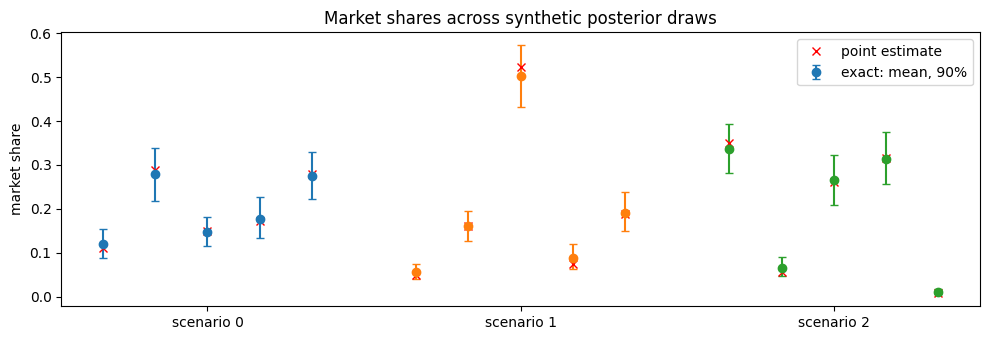

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for s in range(3):
    x = np.arange(5) + 6 * s
    ax.errorbar(x, mean[s], yerr=[mean[s] - lo[s], hi[s] - mean[s]], fmt="o", capsize=3, label="exact: mean, 90%" if s == 0 else None)
    ax.plot(x, pt_market[s], "x", color="r", label="point estimate" if s == 0 else None)
ax.set(xticks=[2 + 6 * s for s in range(3)], xticklabels=[f"scenario {s}" for s in range(3)], ylabel="market share",
       title="Market shares across synthetic posterior draws")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Product-line optimization

There are 720 candidate products: every attribute-level combination,
including all 5 price levels. A line is 3 distinct products, competing against
3 fixed competitor products ($K = 6$, so each share is a 5-dimensional
orthant). The objective is expected margin per buyer,
$\sum_{k \in \text{line}} \text{share}_k \times \text{margin}_k$.

The economics are illustrative: price is \$10 ± \$4 across the price levels,
and unit cost is \$6 plus \$2 per unit of non-price part-worth, so better
levels cost more. Shares come from the aggregate model (true $\beta$,
$\Sigma_A$, $\sigma_P$).

There are $\binom{720}{3} \approx 6.2 \times 10^7$ possible lines. Two
searches:

- **Random**: $10^6$ distinct lines, each scored exactly. Every line has its
  own design, so these are per-row-covariance calls of 100,000 lines each.
- **Greedy + swaps**: add the best product three times, then swap single
  products until nothing improves.

The top 50 random lines and the greedy line are re-scored with SciPy, because
`orthant_cdf`'s error at $d = 5$ can be as large as the profit gaps between
the best lines. RFC's time for the same $10^6$ lines at 0.1-point accuracy
($R = 250{,}000$) is extrapolated from 20 lines.

In [14]:
lev_all, price_all, X_all = rfc.all_products()
comp_idx = rng.choice(len(X_all), 3, replace=False)
X_comp = X_all[comp_idx]
print("competitors: levels", lev_all[comp_idx].tolist(), " prices", price_all[comp_idx], " margins", rfc.dollars(X_comp))

lines = rfc.random_lines(1_000_000, len(X_all), 3, rng)
(prof, _), t_rand = rfc.timed(lambda: rfc.line_profit(X_all[lines], X_comp))
print(f"random search: {len(lines):,} lines in {t_rand:.1f} s ({3*len(lines):,} orthants)")

def greedy():
    line, n_eval = [], 0
    cand = np.arange(len(X_all))
    for _ in range(3):
        rest = np.setdiff1d(cand, line)
        Xl = np.concatenate([np.broadcast_to(X_all[line], (len(rest), len(line), rfc.P)), X_all[rest][:, None]], axis=1)
        p, _ = rfc.line_profit(Xl, X_comp); n_eval += len(rest)
        line.append(int(rest[np.argmax(p)]))
    best = rfc.line_profit(X_all[line][None], X_comp)[0][0]
    improved = True
    while improved:
        improved = False
        for pos in range(3):
            rest = np.setdiff1d(cand, line)
            trial = np.repeat(np.array(line)[None], len(rest), 0); trial[:, pos] = rest
            p, _ = rfc.line_profit(X_all[trial], X_comp); n_eval += len(rest)
            if p.max() > best + 1e-9:
                best, line, improved = p.max(), trial[np.argmax(p)].tolist(), True
    return sorted(line), best, n_eval

(g_line, g_prof, g_n), t_greedy = rfc.timed(greedy)
print(f"greedy + swaps: {g_n:,} lines in {t_greedy:.1f} s")

top = np.argsort(prof)[-50:][::-1]
cands = np.vstack([lines[top], g_line])
sp_prof, sp_sh = rfc.line_profit(X_all[cands], X_comp, method="scipy")
oc_prof = np.r_[prof[top], g_prof]
check7 = pd.DataFrame({"line": [tuple(c) for c in cands], "source": ["random"] * 50 + ["greedy"],
                       "orthant_cdf profit": oc_prof, "SciPy profit": sp_prof})
check7["orthant rank"] = check7["orthant_cdf profit"].rank(ascending=False).astype(int)
check7["SciPy rank"] = check7["SciPy profit"].rank(ascending=False).astype(int)
display(check7.sort_values("SciPy profit", ascending=False).head(8))
best_row = check7.loc[check7["SciPy profit"].idxmax()]
print("best line by SciPy:", best_row.line, best_row.source)
for i in best_row.line:
    print("   levels", lev_all[i].tolist(), f"price {price_all[i]:+.1f}", f"margin ${rfc.dollars(X_all[i]):.2f}")
print(f"|orthant_cdf - SciPy| profit on these 51 lines: median {np.median(np.abs(oc_prof-sp_prof)):.4f}, "
      f"max {np.abs(oc_prof-sp_prof).max():.4f}; spread of the top 50 (SciPy): {sp_prof[:50].max()-sp_prof[:50].min():.4f}")

Xs20 = np.concatenate([X_all[lines[:20]], np.broadcast_to(X_comp, (20, 3, rfc.P))], axis=1)
_, t20 = rfc.timed(lambda: rfc.rfc_shares(Xs20, 250_000, rng))
timing7 = pd.DataFrame([
    ["exact, random search", f"{len(lines):,}", t_rand, "measured"],
    ["exact, greedy + swaps", f"{g_n:,}", t_greedy, "measured"],
    ["RFC a, R=250,000, same 1e6 lines", f"{len(lines):,}", t20 / 20 * len(lines), "extrapolated from 20"],
], columns=["method", "lines", "seconds", "how"])
timing7

competitors: levels [[1, 2, 0, 0, 1], [3, 2, 2, 0, 0], [1, 1, 2, 1, 0]]  prices [-1.   0.5 -0.5]  margins [-2.4  6.4 -0.5]


random search: 1,000,000 lines in 86.1 s (3,000,000 orthants)


greedy + swaps: 4,308 lines in 5.1 s


,line,source,orthant_cdf profit,SciPy profit,orthant rank,SciPy rank
50,"(279, 454, 459)",greedy,0.6823,0.6772,1,1
0,"(279, 454, 519)",random,0.6595,0.6568,2,2
1,"(279, 443, 518)",random,0.6445,0.6471,3,3
2,"(274, 279, 449)",random,0.6388,0.6457,4,4
3,"(279, 443, 519)",random,0.6353,0.6371,5,5
4,"(279, 454, 623)",random,0.6330,0.6361,6,6
10,"(269, 459, 639)",random,0.6232,0.6289,12,7
8,"(274, 448, 454)",random,0.6246,0.6269,10,8


best line by SciPy: (np.int64(279), np.int64(454), np.int64(459)) greedy
   levels [1, 1, 1, 1, 1] price +1.0 margin $3.70
   levels [2, 1, 1, 1, 0] price +1.0 margin $4.70
   levels [2, 1, 1, 1, 1] price +1.0 margin $4.50
|orthant_cdf - SciPy| profit on these 51 lines: median 0.0040, max 0.0188; spread of the top 50 (SciPy): 0.0787


,method,lines,seconds,how
0,"exact, random search","1,000,000",86.0787,measured
1,"exact, greedy + swaps","4,308",5.0671,measured
2,"RFC a, R=250,000, same 1e6 lines","1,000,000",18010.2667,extrapolated from 20


## 8. Cannibalization / cross-price effects

The base scenario is the first plain set ($K = 5$). For each product $j$ its
price moves up one step (+0.5 on the price code), and the matrix entry
$[k, j]$ is the resulting change in product $k$'s share. The exact matrix
comes from SciPy, and `orthant_cdf` is checked against it.

RFC estimates the same matrix by finite differences of two simulations,
either with **independent** draws or with **common random numbers** (the same
draws for base and perturbed scenarios, as a fixed simulator seed gives).
Over 20 replications the table reports the mean absolute error, the
replication standard deviation of an entry, and how often an off-diagonal
entry has the wrong sign. Raising a rival's price should never lower a share.

In [15]:
X_base = X[np.where(kind == "plain")[0][0]]
pert = np.repeat(X_base[None], 5, 0)
for j in range(5):
    pert[j, j, -1] += 0.5
all8 = np.concatenate([X_base[None], pert])
ex8 = rfc.shares_scipy(all8)
D_exact = (ex8[1:] - ex8[0]).T                       # [k, j]
oc8 = rfc.shares_orthant(all8)
D_oc = (oc8[1:] - oc8[0]).T
display(pd.DataFrame(D_exact, index=[f"share {k}" for k in range(5)], columns=[f"price {j} +1 step" for j in range(5)]))
print(f"orthant_cdf matrix vs exact: max |error| {np.abs(D_oc - D_exact).max():.4f}")

off = ~np.eye(5, dtype=bool)
rows8 = []
for R in (10_000, 100_000):
    for crn in (False, True):
        mats = []
        for rep in range(20):
            if crn:     # one call: the same draws for the base and all perturbed scenarios
                sh = rfc.rfc_shares(all8, R, rng)
            else:       # one call per scenario: fresh draws each
                sh = np.vstack([rfc.rfc_shares(all8[i:i + 1], R, rng) for i in range(len(all8))])
            mats.append((sh[1:] - sh[0]).T)
        mats = np.array(mats)
        rows8.append(dict(R=R, draws="common" if crn else "independent",
                          mean_abs_err=np.abs(mats - D_exact).mean(), entry_sd=mats.std(axis=0).mean(),
                          wrong_sign_offdiag=np.mean(mats[:, off] < 0), mats=mats))
rfc8 = pd.DataFrame(rows8)
display(rfc8.drop(columns="mats"))
print(f"typical |exact entry|: diagonal {np.abs(np.diag(D_exact)).mean():.4f}, off-diagonal {np.abs(D_exact[off]).mean():.4f}")

,price 0 +1 step,price 1 +1 step,price 2 +1 step,price 3 +1 step,price 4 +1 step
share 0,-0.0054,9.2446e-05,0.0004,0.0070,0.0030
share 1,0.0001,-1.7453e-03,0.0002,0.0024,0.0011
share 2,0.0004,2.0700e-04,-0.0064,0.0089,0.0042
share 3,0.0030,8.6598e-04,0.0034,-0.1747,0.0912
share 4,0.0019,5.7914e-04,0.0023,0.1564,-0.0995


orthant_cdf matrix vs exact: max |error| 0.0004


,R,draws,mean_abs_err,entry_sd,wrong_sign_offdiag
0,10000,independent,0.0024,0.0029,0.2425
1,10000,common,0.0008,0.0009,0.0150
2,100000,independent,0.0008,0.0010,0.1475
3,100000,common,0.0002,0.0002,0.0000


typical |exact entry|: diagonal 0.0575, off-diagonal 0.0144


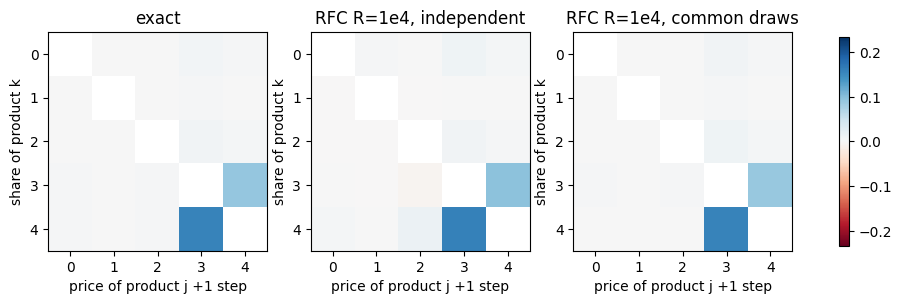

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
v = np.abs(D_exact[off]).max() * 1.5
for a, (M, t) in zip(ax, [(D_exact, "exact"), (rfc8.mats[0][0], "RFC R=1e4, independent"), (rfc8.mats[1][0], "RFC R=1e4, common draws")]):
    im = a.imshow(np.where(off, M, np.nan), cmap="RdBu", vmin=-v, vmax=v)
    a.set(title=t, xlabel="price of product j +1 step", ylabel="share of product k")
plt.colorbar(im, ax=ax, shrink=.8); plt.show()

## Summary

In [17]:
import json
fair = json.load(open("product_line_fair.json"))  # written by product_line_fair.ipynb
fair_R = {r["R"]: r for r in fair["table"]}
c = conv.set_index(["variant", "R"])
R_hit = conv[(conv.variant == "a") & (conv.max_err <= 0.001)].R.min()
summary = pd.DataFrame([
    ["orthant_cdf vs SciPy, 750 shares (max / median)", f"{e.max():.4f} / {np.median(e):.4f}"],
    ["RFC a, R=1e4 vs exact (max / median)", f"{c.loc[('a', 10_000), 'max_err']:.4f} / {c.loc[('a', 10_000), 'median_err']:.4f}"],
    ["RFC a, R=1e6 vs exact (max / median)", f"{c.loc[('a', 1_000_000), 'max_err']:.4f} / {c.loc[('a', 1_000_000), 'median_err']:.4f}"],
    ["smallest R with RFC a max error <= 0.001 (150 sets)", f"{R_hit:,}" if pd.notna(R_hit) else "> 1e6"],
    ["RFC b vs exact a, R=1e6 (max / mean)", f"{c.loc[('b', 1_000_000), 'max_err']:.4f} / {c.loc[('b', 1_000_000), 'mean_err']:.4f}"],
    ["twins combined share: |RFC a - exact|, |RFC b - exact| (mean)",
     f"{np.abs(twins['RFC a'] - twins['exact a: twins combined']).mean():.4f}, "
     f"{np.abs(twins['RFC b'] - twins['exact a: twins combined']).mean():.4f}"],
    ["1e6 respondents: RFC a at 0.1-pt / SciPy / orthant_cdf (s)",
     f"{timing.iloc[-1, 0]:.3g} / {timing.iloc[-1, 2]:.3g} / {timing.iloc[-1, 4]:.3g}"],
] + [[f"test MAE, data {r.dgp}: {r.method}", f"{r.test_MAE:.4f}"] for r in fits.itertuples()] + [
    ["HB (synthetic): |point estimate - posterior mean share| (mean / max)", f"{d.mean():.4f} / {d.max():.4f}"],
    ["HB (synthetic): 90% interval width, mean", f"{(shares6.hi90 - shares6.lo90).mean():.4f}"],
    ["HB (synthetic): pairs reversed / uncertain, of 100", f"{rev} / {unc}"],
    ["HB 1000x500x10: exact / RFC R=250 / RFC R=250k (s)",
     f"{timing6.seconds[0]:.3g} / {timing6.seconds[1]:.3g} / {timing6.seconds[2]:.3g}"],
    ["product line: best line (SciPy-checked), source", f"{best_row.line}, {best_row.source}"],
    ["product line: 1e6 lines exact / RFC at 0.1 pt (s)", f"{timing7.seconds[0]:.3g} / {timing7.seconds[2]:.3g}"],
    ["product line: |orthant_cdf - SciPy| profit, max (top 51)", f"{np.abs(oc_prof-sp_prof).max():.4f}"],
    ["cross-price matrix: orthant_cdf max |error|", f"{np.abs(D_oc - D_exact).max():.4f}"],
] + [[f"cross-price matrix: RFC R={r.R:.0e}, {r.draws} draws, mean |err| / wrong-sign", f"{r.mean_abs_err:.4f} / {r.wrong_sign_offdiag:.2f}"]
     for r in rfc8.itertuples()] + [["product line, RFC common draws: smallest R with same best line and top-10 overlap >= 9",
        f"{fair['R_min']:,}" if fair["R_min"] else
        f"> 1e4 (R=1e4: top-10 {fair_R[10000]['top10_overlap']}, {fair_R[10000]['seconds']:.0f} s; orthant_cdf {fair['t_orth']:.0f} s)"]],
    columns=["quantity", "value"]).set_index("quantity")
summary

,value
quantity,
"orthant_cdf vs SciPy, 750 shares (max / median)",0.0183 / 0.0007
"RFC a, R=1e4 vs exact (max / median)",0.0149 / 0.0016
"RFC a, R=1e6 vs exact (max / median)",0.0015 / 0.0001
smallest R with RFC a max error <= 0.001 (150 sets),> 1e6
"RFC b vs exact a, R=1e6 (max / mean)",0.0143 / 0.0035
"twins combined share: |RFC a - exact|, |RFC b - exact| (mean)","0.0002, 0.0072"
1e6 respondents: RFC a at 0.1-pt / SciPy / orthant_cdf (s),1.48e+04 / 5.13e+04 / 15.4
"test MAE, data a: truth",0.0129
"test MAE, data a: exact, diag",0.0136


## Where RFC is good enough, and where it is not

These findings come from the outputs above, on this synthetic design (K = 5,
10 part-worths, σ_P = 0.5) and one seed. "Exact" means the exact
probabilities of model (a). `orthant_cdf` computes them approximately, and
its error against SciPy is listed separately.

**RFC is good enough when:**

- **The quantity is a market share averaged over many respondents or draws.**
  The Monte Carlo noise averages out across respondents, so with 1,000
  respondents about 250 draws per (respondent, draw) is enough for 0.1 share
  points. At 1,000 respondents × 500 draws × 10 scenarios, RFC took 205 s
  against 130 s for the exact shares. Its posterior-mean shares were within
  0.004 of exact. At this scale the two cost about the same.
- **Duplicates and near-duplicates, with normal product noise.** RFC (a)
  matched the exact combined twin share to 0.0002 and the near-twin share
  difference to 0.0002 (R = 10⁶). RFC's handling of duplicates belongs to the
  model and is not a Monte Carlo artifact.
- **Cross-price effects, if the simulator uses common random numbers** (a fixed
  seed shared by the base and changed scenarios). At R = 10⁵ with common
  draws, the matrix error was 0.0002 and no off-diagonal entry had the wrong
  sign. Even at R = 10⁴ the error was 0.0008, with 1.5% wrong signs.

- **Picking the single best product line, with common random numbers.**
  R = 10³ picked the same best line of 10⁶ as `orthant_cdf` (profit gap 0) in
  46 s, against 41 s for `orthant_cdf` (`product_line_fair.ipynb`). That line
  has near-duplicate products (difference correlation ≥ 0.9), where
  `orthant_cdf` is least accurate; in section 7, SciPy agreed on it.

**RFC is not good enough when:**

- **Each individual share must be accurate to 0.1 points.** That takes about
  250,000 draws per scenario. At 10⁶ respondents it is about 4 hours
  (extrapolated), against 15 s for `orthant_cdf`. Across the 150 test sets,
  10⁶ draws still left a worst-case share error of 0.0015.
- **Cross-price effects with independent draws per scenario.** At R = 10⁵,
  15% of the off-diagonal entries still had the wrong sign. These are the
  small entries (below 0.001), but a cannibalization table with "negative
  substitution" would be wrong.
- **Ranking product lines beyond the winner.** With common random numbers
  (`product_line_fair.ipynb`), R = 10⁴ draws took 436 s for 10⁶ lines and still got
  only 8 of the top 10 (Spearman 0.82 on the top 1,000). `orthant_cdf` took
  41 s, so any RFC setting that gets 9 of the top 10 together with the
  winner takes more than 10.6 times as long. At 0.1-point accuracy per share
  (R = 250,000, independent draws), RFC would take about 5 hours
  (extrapolated).
- **Fitting the variances.** On data from model (a), maximum likelihood on
  exact probabilities with a diagonal Σ_A reached holdout MAE 0.0136, against
  0.0129 at the true parameters and 0.019–0.020 for grid-searched RFC.
  - With the same two parameters as the grid, the exact fit reached 0.0158.
    So part of the gain comes from fitting more parameters, which a grid
    cannot do, and part from the coarse 8×8 grid: it picked (0.35, 0.47)
    where the optimum was near (0.40, 0.54).
  - On data from model (b), where the exact model is misspecified, the
    two-parameter exact fit and both RFC grids were tied (0.0165–0.0169).
    The diagonal exact fit was still best (0.0137).

**Other findings:**

- **Which error distribution RFC uses matters more than how many draws.**
  RFC (b), with Gumbel product noise, differs from model (a) by 0.0035 per
  share on average (0.014 at most), and 0.007 on combined twin shares. Beyond
  about R = 3·10⁴ the change of distribution dominates the Monte Carlo noise.
  Neither is "right"; they are different models.
- **`orthant_cdf` is not exact.**
  - On per-row covariances at d = 4 its share error was 0.0007 (median) and
    0.018 (max). That is better than RFC at R = 10⁴ but worse than RFC at
    R = 10⁶.
  - On product-line profit at d = 5 its error was up to 0.019, against a
    0.079 spread across the top 50 lines. The SciPy re-scoring agreed on the
    top six lines and on the winner.
  - Where every share must be within about 0.005, check it against SciPy.
- **HB section.** The interval widths follow from the synthetic population-mean
  uncertainty (sd 0.08) and are not a finding. Using posterior means only moved
  shares by 0.0095 on average (0.032 at most), with no ranking reversals among
  100 pairs. 22 of the 100 pairs had a 90% interval of the share difference
  that included 0. A point-estimate simulator cannot report that.
